### Import necessary libraries and modules

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor  
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor


### Load data

In [118]:
df=pd.read_csv('housing.csv') 

### Understanding the data 


In [119]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


We have a complete dataset in the majority of variables. However, missingness occurs in the variable total_bedrooms (n=207)

### Split our data

In [120]:
train,test = train_test_split(df, test_size=0.2, random_state=42)   


### EDA on training dataset


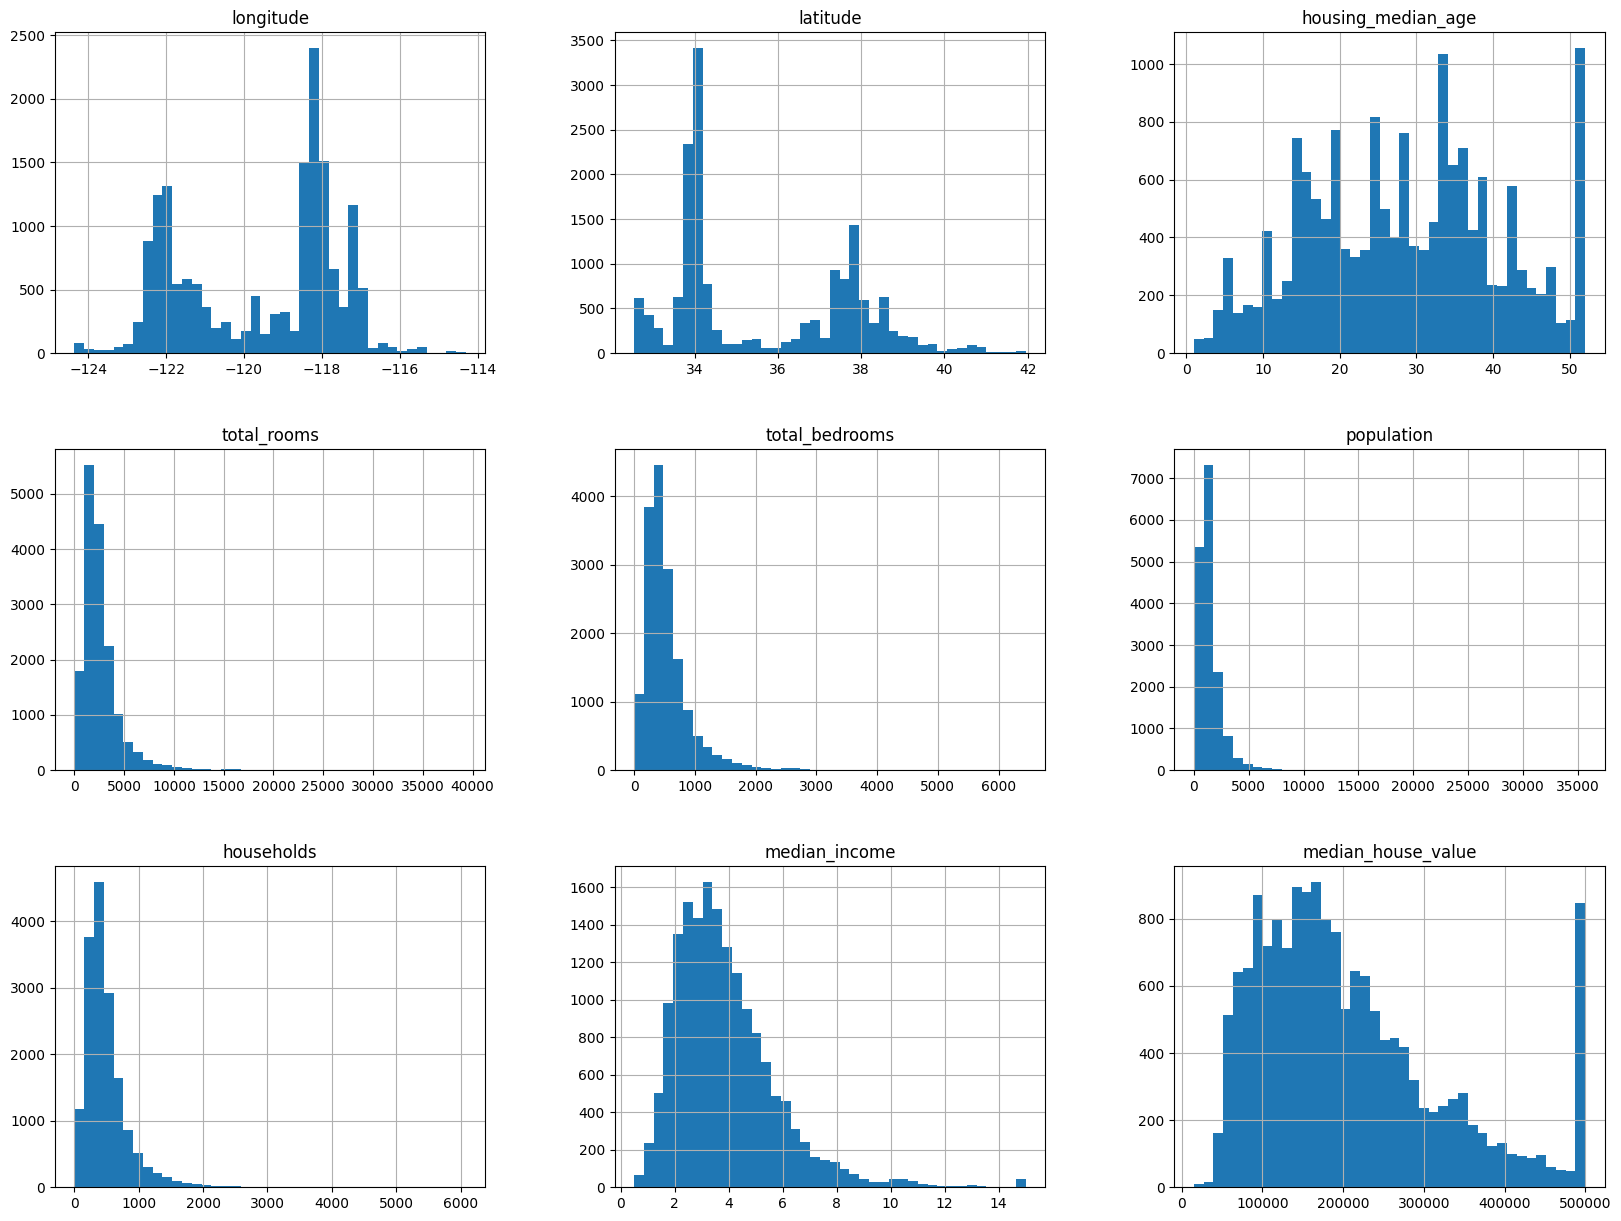

In [121]:
train.hist(bins=40, figsize=(20,15))
plt.show()

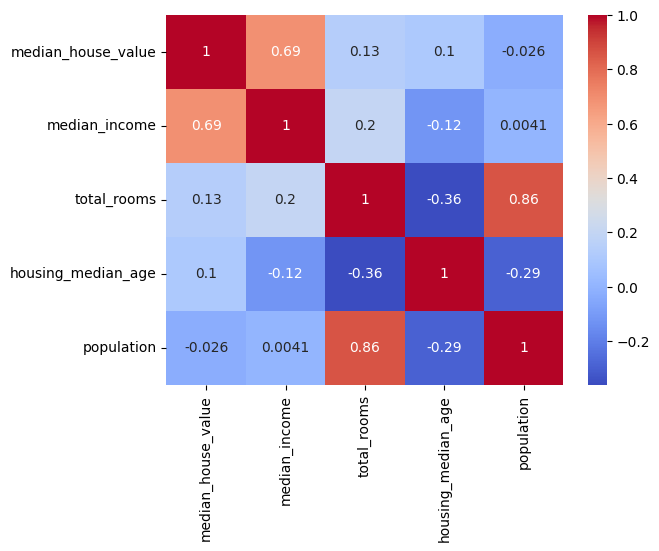

In [122]:
corr= train[['median_house_value','median_income','total_rooms','housing_median_age','population']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [123]:
train.columns
#convert to category 
train['ocean_proximity'] = train['ocean_proximity'].astype('category')
train['total_bedrooms'] = train['total_bedrooms'].astype('float')

train[['ocean_proximity']].value_counts(normalize=True)



ocean_proximity
<1H OCEAN          0.444586
INLAND             0.316558
NEAR OCEAN         0.126332
NEAR BAY           0.112282
ISLAND             0.000242
Name: proportion, dtype: float64

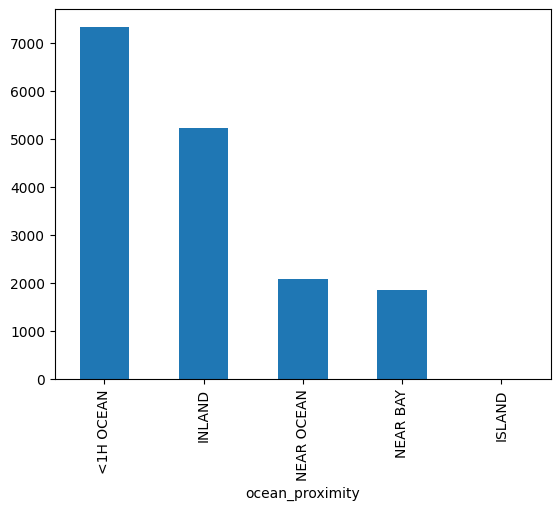

In [124]:
train['ocean_proximity'].value_counts().plot(kind='bar')
plt.show()

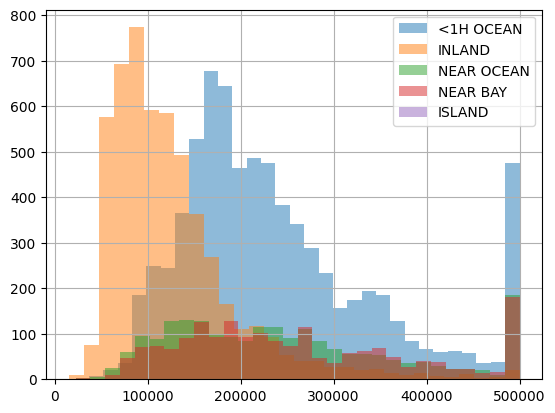

In [125]:
train.query('ocean_proximity == "<1H OCEAN"')['median_house_value'].hist(bins=30, alpha=0.5, label='<1H OCEAN')
train.query('ocean_proximity == "INLAND"')['median_house_value'].hist(bins=30, alpha=0.5, label='INLAND')
train.query('ocean_proximity == "NEAR OCEAN"')['median_house_value'].hist(bins=30, alpha=0.5, label='NEAR OCEAN')
train.query('ocean_proximity == "NEAR BAY"')['median_house_value'].hist(bins=30, alpha=0.5, label='NEAR BAY')
train.query('ocean_proximity == "ISLAND"')['median_house_value'].hist(bins=30, alpha=0.5, label='ISLAND')
plt.legend()    

In [126]:
x_train = train.drop('median_house_value', axis=1)
y_train = train['median_house_value']

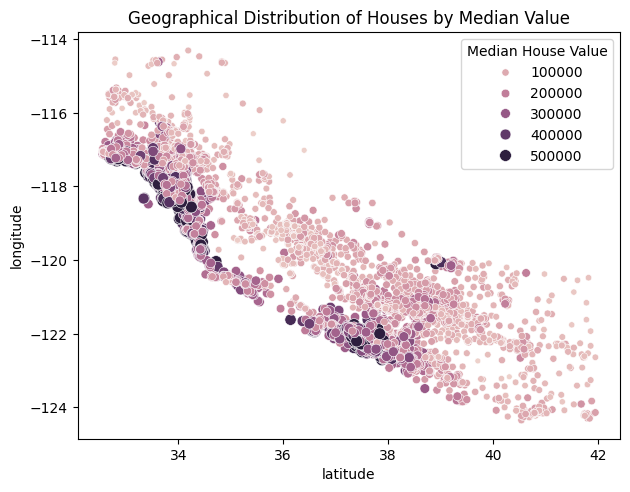

In [143]:
sns.scatterplot(
    x=x_train['latitude'], 
    y=x_train['longitude'],
    hue=y_train,
    size=y_train
)
plt.legend(title='Median House Value')
plt.tight_layout()
plt.title('Geographical Distribution of Houses by Median Value')
plt.show()

### Evaluation

In [127]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'r2'

# Define features
numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
categorical_features = ['ocean_proximity']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_features)
    ]
)

### Models

In [ ]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', LinearRegression())
    ])

baselinegrid = GridSearchCV(estimator=baseline_pipeline, param_grid={}, scoring=scoring, cv=cv, n_jobs=-1)
baselinegrid.fit(x_train, y_train)
print("Linear Regression - CV R2:", baselinegrid.best_score_)

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', Lasso())
    ])
lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}
Lasso_grid = GridSearchCV(estimator=lasso_pipeline, param_grid=lasso_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Lasso_grid.fit(x_train, y_train)    
print("Lasso - CV R2:", Lasso_grid.best_score_)

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', Ridge())
    ])
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(estimator=ridge_pipeline, param_grid=ridge_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
ridge_grid.fit(x_train, y_train)
print("Ridge - CV R2:", ridge_grid.best_score_)

elastic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', ElasticNet())
    ])

elastic_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
elastic_grid = GridSearchCV(estimator=elastic_pipeline, param_grid=elastic_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
elastic_grid.fit(x_train, y_train)
print("ElasticNet - CV R2:", elastic_grid.best_score_)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', RandomForestRegressor(random_state=42))
    ])

rf_param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [1, 10, 20]
}
rf_grid = GridSearchCV(estimator=rf_pipeline, param_grid=rf_param_grid, scoring=scoring, cv=cv, n_jobs=-1
 )
rf_grid.fit(x_train, y_train)
print("Random Forest - CV R2:", rf_grid.best_score_)

Gradiient_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', GradientBoostingRegressor(random_state=42))
    ])
grnbs_param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [1, 10, 20]
}
Gradiient_grid = GridSearchCV(estimator=Gradiient_pipeline, param_grid=grnbs_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Gradiient_grid.fit(x_train, y_train)
print("Gradient Boosting - CV R2:", Gradiient_grid.best_score_)

cv_results = []

cv_results.append({"model": "Linear Regression", "CV_R2": baselinegrid.best_score_})
cv_results.append({"model": "Ridge", "CV_R2": ridge_grid.best_score_})
cv_results.append({"model": "Lasso", "CV_R2": Lasso_grid.best_score_})
cv_results.append({"model": "Elastic Net", "CV_R2": elastic_grid.best_score_})
cv_results.append({"model": "Random Forest", "CV_R2": rf_grid.best_score_})
cv_results.append({"model": "Gradient Boosting", "CV_R2": Gradiient_grid.best_score_})

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_R2", ascending=True)
cv_results_df

Linear Regression - CV R2: 0.6476757451183028
Lasso - CV R2: 0.6477150866679181
Ridge - CV R2: 0.647760056039498


c:\Users\chn03\Desktop\Machine learning\Housing price\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.866e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


ElasticNet - CV R2: 0.6477662451136729
Random Forest - CV R2: 0.8187424669060018


,model,CV_R2
0,Linear Regression,0.647676
2,Lasso,0.647715
1,Ridge,0.647760
3,Elastic Net,0.647766
4,Random Forest,0.818742
5,Gradient Boosting,0.827988


### Selecting the best model

In [136]:
best_model_name = cv_results_df.iloc[5]["model"]
print("Best model according to CV:", best_model_name)

best_estimator_lookup = {
    "LinearRegression": baselinegrid.best_estimator_,
    "Ridge": ridge_grid.best_estimator_,
    "Lasso": Lasso_grid.best_estimator_,
    "Elastic Net": elastic_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": Gradiient_grid.best_estimator_
}

best_model = best_estimator_lookup[best_model_name]
best_model

Best model according to CV: Gradient Boosting


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Feature importance 


C:\Users\chn03\AppData\Local\Temp\ipykernel_16300\2076063709.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


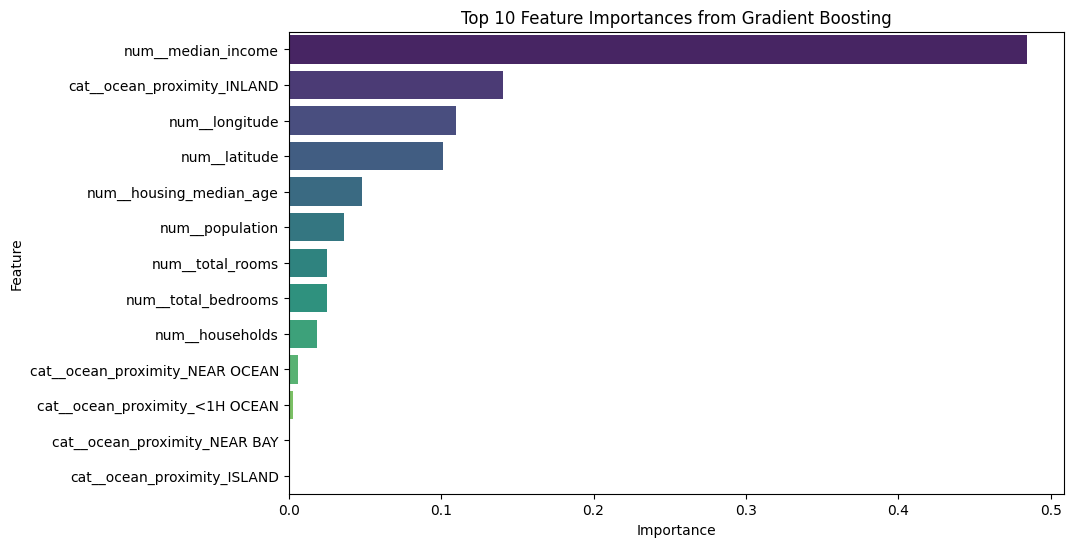

In [139]:
best_model = Gradiient_grid.best_estimator_
model_step = best_model.named_steps['model']
preprocessor_step = best_model.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()
feature_importances = model_step.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Feature Importances from Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()



## Model approach 2
In this second approach, we will model our data similar to the first approach. However, there are two important differences.

- We will proceed with only random forest and gradient boosting. This is because these two models showed superior performance with a huge gap from the other models and it is unlikely that any changes made on the second iteration will improve them so much that they can out perform the other two models.

- In this second iteration of the models, we will perform feature inginearing and also simplify the model. 

At the end, the best appraoch and the best model will be selected and tested using the test data. 

### Feature ingineering 

### Models

In [ ]:

rf_pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', RandomForestRegressor(random_state=42))
    ])

rf_param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [1, 10, 20]
}
rf_grid = GridSearchCV(estimator=rf_pipeline2, param_grid=rf_param_grid, scoring=scoring, cv=cv, n_jobs=-1
 )
rf_grid.fit(x_train, y_train)
print("Random Forest - CV R2:", rf_grid.best_score_)

Gradiient_pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', GradientBoostingRegressor(random_state=42))
    ])
grnbs_param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [1, 10, 20]
}
Gradiient_grid = GridSearchCV(estimator=Gradiient_pipeline2, param_grid=grnbs_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Gradiient_grid.fit(x_train, y_train)
print("Gradient Boosting - CV R2:", Gradiient_grid.best_score_)

cv_results2 = []

cv_results2.append({"model": "Linear Regression", "CV_R2": baselinegrid.best_score_})
cv_results2.append({"model": "Ridge", "CV_R2": ridge_grid.best_score_})
cv_results2.append({"model": "Lasso", "CV_R2": Lasso_grid.best_score_})
cv_results2.append({"model": "Elastic Net", "CV_R2": elastic_grid.best_score_})
cv_results2.append({"model": "Random Forest", "CV_R2": rf_grid.best_score_})
cv_results2.append({"model": "Gradient Boosting", "CV_R2": Gradiient_grid.best_score_})

cv_results_df = pd.DataFrame(cv_results2).sort_values("CV_R2", ascending=True)
cv_results_df